# Лабораторная 3. Наращивание и сужение

Дилатация (наращивание) и эрозия (сужение) реализованы вручную: для каждого пикселя смотрим окрестность по структурному элементу (SE).

- **дилатация** — максимум по позициям, где в SE стоят единицы (объект растёт).
- **эрозия** — минимум по тем же позициям (объект сжимается).

Нули в SE игнорируются. SE захардкожен, но меняется в одном месте: размер, единицы/нули или круг.

Потом тот же SE подаётся в `scipy.ndimage`, свой результат вычитается из библиотечного.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

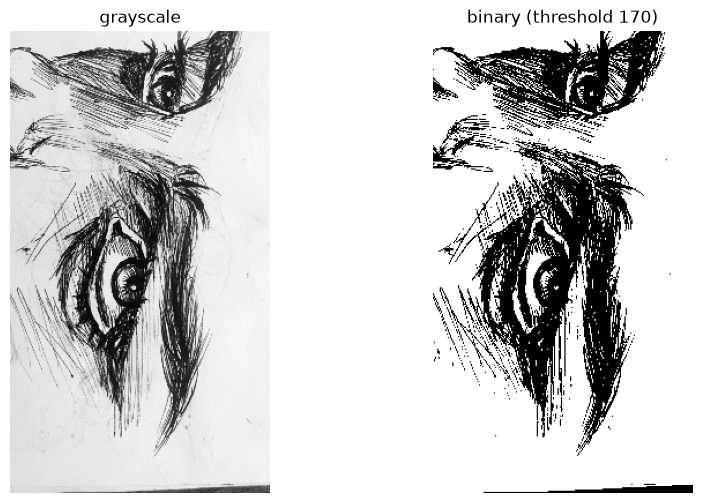

((400, 225), np.uint8(0), np.uint8(255))

In [2]:
#Функция загрузки и конвертации
def load_gray(path: str) -> np.ndarray:
    img = plt.imread(path)      #Загрузка
    if img.dtype == np.float32 or img.dtype == np.float64:       #Нормализация
        img = np.clip(img * 255.0, 0, 255)
    img = img.astype(np.uint8)
    if img.ndim == 3:           #Отсекаем канал цвета изображения если есть
        rgb = img[..., :3]
        gray = (0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2])
        return gray.astype(np.uint8)
    return img


gray = load_gray("cat.png")
# чуть уменьшим, чтобы ручные циклы по окрестности не тормозили на обоях
max_side = 400          #Ограничение макс размера стороны
h, w = gray.shape
scale = max_side / max(h, w)        #Масштабирование
if scale < 1:
    new_h, new_w = int(h * scale), int(w * scale)
    yy = (np.linspace(0, h - 1, new_h)).astype(int)
    xx = (np.linspace(0, w - 1, new_w)).astype(int)
    gray = gray[np.ix_(yy, xx)]

binary = (gray > 170).astype(np.uint8) * 255        #Бинаризация по порогу

#Визализация
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ax[0].imshow(gray, cmap="gray")
ax[0].set_title("grayscale")
ax[0].axis("off")
ax[1].imshow(binary, cmap="gray")
ax[1].set_title("binary (threshold 170)")
ax[1].axis("off")
plt.show()
gray.shape, binary.min(), binary.max()

## Структурный элемент

Менять нужно только ячейку ниже: `se_rectangle(h, w)`, отдельные нули, либо `se_disk(radius)`. Origin — центр матрицы (`shape // 2`). Для нечётных размеров он совпадает с OpenCV/`scipy`.

SE shape: (5, 5)
[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


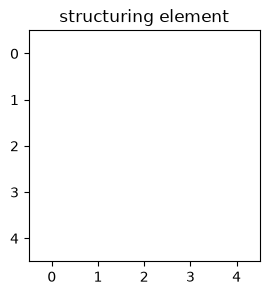

In [3]:
def se_rectangle(height: int, width: int) -> np.ndarray:
    '''Создание прямоугольника'''
    return np.ones((height, width), dtype=np.uint8)


def se_disk(radius: int) -> np.ndarray:
    '''Создание диска'''
    y, x = np.ogrid[-radius : radius + 1, -radius : radius + 1]
    return (x * x + y * y <= radius * radius).astype(np.uint8)


# --- менять SE здесь ---
SE = se_rectangle(5, 5)
# SE[2, 2] = 0          # выколоть центр
# SE = se_disk(3)       # круг
# ----------------------

print("SE shape:", SE.shape)
print(SE)

plt.figure(figsize=(3, 3))
plt.imshow(SE, cmap="gray", vmin=0, vmax=1)
plt.title("structuring element")
plt.xticks(range(SE.shape[1]))
plt.yticks(range(SE.shape[0]))
plt.show()

## Свои дилатация и эрозия

Для пикселя `(y, x)` берём все смещения `(dy, dx)`, где `SE[dy, dx] != 0`, и читаем `image[y + dy - cy, x + dx - cx]` (с padding `0` за границей).

- дилатация: `max` по этой окрестности
- эрозия: `min`

На бинарной картинке это то же самое, что «есть ли хоть один белый сосед» / «все соседи белые».

In [ ]:
def _origin(se: np.ndarray) -> tuple[int, int]:
    '''Вспомогательная функция для нахождения координаты центрального пикселя структурного элемента se'''
    kh, kw = se.shape
    return kh // 2, kw // 2


def _neighborhood_stack(image: np.ndarray, se: np.ndarray) -> np.ndarray:
    """
    Векторизованный генератор окрестностей
    Готовит данные для быстрых матричных операций    
    Стек окрестностей: [k, H, W], k — только единицы SE.

    Выражение padded[oy : oy + h, ox : ox + w] берет срез из падированного изображения размером HxW, 
    сдвинутый на смещение (oy, ox).
    Генератор [...] делает такой сдвиг для каждого активного элемента ядра.
    np.stack(..., axis=0) «склеивает» все полученные 2D-картинки в один 3D-массив (стек) формы [k, H, W],
    где k — количество единиц в ядре. Теперь под каждым пикселем изображения на глубине k лежат все его соседи, 
    накрытые ядром."""
    se = np.asarray(se)
    image = np.asarray(image)
    cy, cx = _origin(se)
    kh, kw = se.shape
    #Обшиваем оригинал нулевой рамкой. Это нужно чтобы при наложении ядра на края изображения не выходить за границы массива
    padded = np.pad(
        image,
        ((cy, kh - 1 - cy), (cx, kw - 1 - cx)),     #((pad_top, pad_bottom), (pad_left, pad_right))
        mode="constant",
        constant_values=0,
    )
    h, w = image.shape
    offsets = np.argwhere(se != 0) #Находим относительные координатыточек ядра, которые равны единицы
    #Для каждого смещения oy, ox делается срез падированного изображения размера (H,W). В результате полуается [k, H, W], где k - единицы.
    return np.stack([padded[oy : oy + h, ox : ox + w] for oy, ox in offsets], axis=0)

#dilate\erode 
def dilate(image: np.ndarray, se: np.ndarray) -> np.ndarray:
    return _neighborhood_stack(image, se).max(axis=0).astype(image.dtype) #Вычисляем максимум по оси нуль. В итоговом пикселе оказывается максимальное значение среди его соседей


def erode(image: np.ndarray, se: np.ndarray) -> np.ndarray:
    return _neighborhood_stack(image, se).min(axis=0).astype(image.dtype) #Вычисляем минимум по оси нуль. В итоговом пикселе оказывается минимально значение среди его соседей

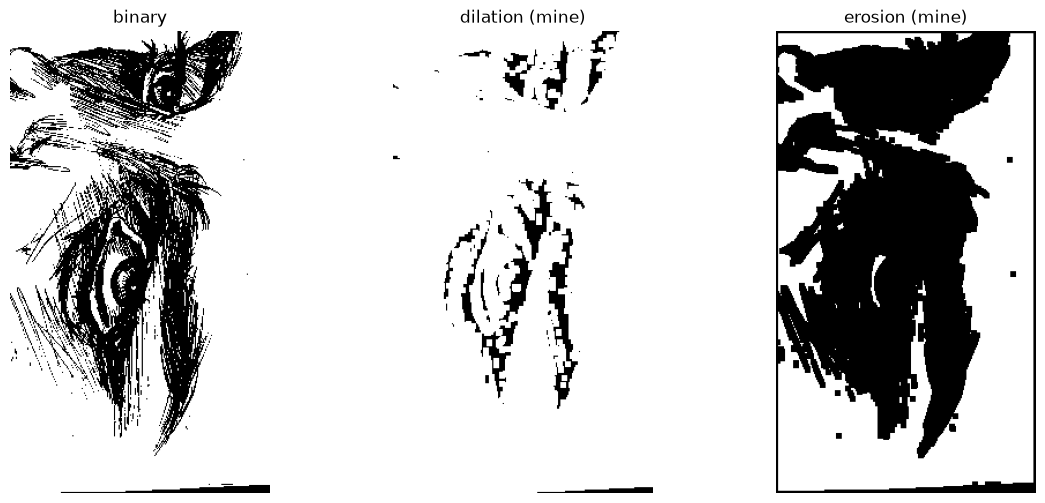

In [6]:
my_dil = dilate(binary, SE)
my_ero = erode(binary, SE)

fig, ax = plt.subplots(1, 3, figsize=(14, 6))
ax[0].imshow(binary, cmap="gray")
ax[0].set_title("binary")
ax[1].imshow(my_dil, cmap="gray")
ax[1].set_title("dilation (mine)")
ax[2].imshow(my_ero, cmap="gray")
ax[2].set_title("erosion (mine)")
for a in ax:
    a.axis("off")
plt.show()

## Сравнение с `scipy.ndimage`

Тот же SE как `footprint`. `mode="constant", cval=0` — как наш padding нулями за границей (у scipy по умолчанию `reflect`, из-за этого края могли бы разъехаться).

dilation: nonzero |lib - mine| = 0, max = 0
erosion: nonzero |lib - mine| = 0, max = 0


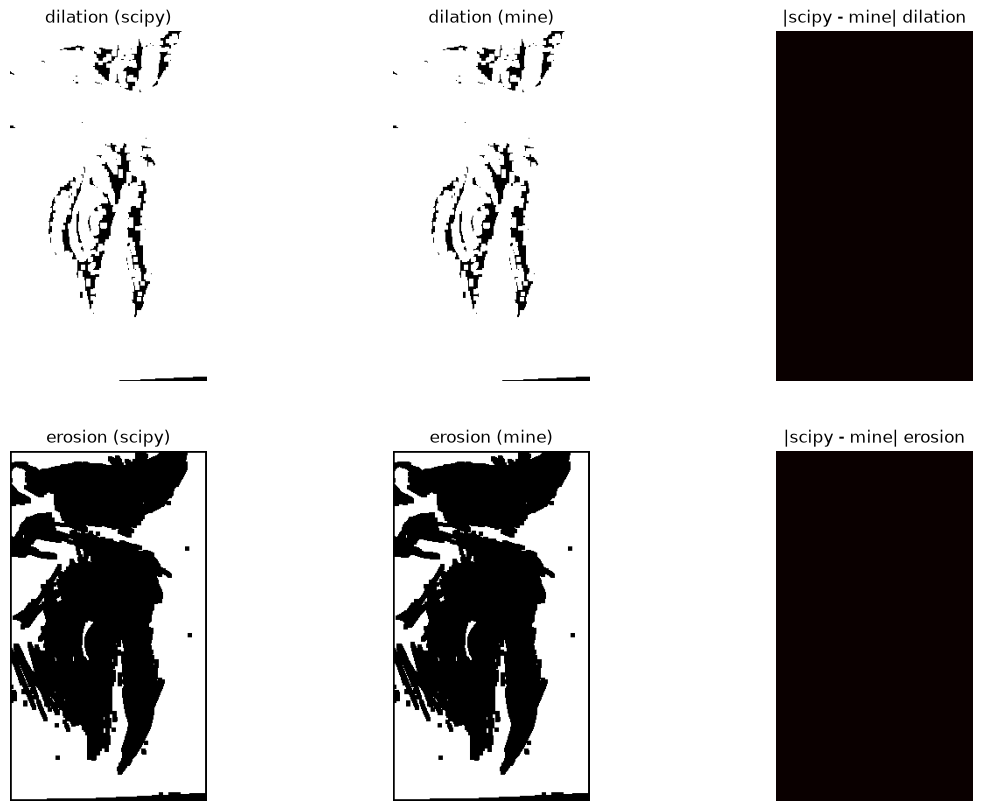

In [ ]:
def library_dilate(image, se):
    return ndimage.grey_dilation(
        image, footprint=se.astype(bool), mode="constant", cval=0
    ).astype(image.dtype)


def library_erode(image, se):
    return ndimage.grey_erosion(
        image, footprint=se.astype(bool), mode="constant", cval=0
    ).astype(image.dtype)

#Функция сравнения и поиска ошибок
def compare(mine: np.ndarray, lib: np.ndarray, title: str) -> np.ndarray:
    diff = np.abs(lib.astype(np.int16) - mine.astype(np.int16))
    n = int(np.count_nonzero(diff)) #Считаем количество отличающихся пикселей
    print(f"{title}: nonzero |lib - mine| = {n}, max = {int(diff.max()) if n else 0}")
    if n:
        ys, xs = np.nonzero(diff)
        print(f"  first mismatches (y, x, lib, mine):")
        for y, x in zip(ys[:10], xs[:10]):
            print(f"    ({y}, {x})  lib={lib[y, x]}  mine={mine[y, x]}")
    return diff.astype(np.uint16)


lib_dil = library_dilate(binary, SE)
lib_ero = library_erode(binary, SE)

diff_dil = compare(my_dil, lib_dil, "dilation")
diff_ero = compare(my_ero, lib_ero, "erosion")

fig, ax = plt.subplots(2, 3, figsize=(14, 10))
ax[0, 0].imshow(lib_dil, cmap="gray")
ax[0, 0].set_title("dilation (scipy)")
ax[0, 1].imshow(my_dil, cmap="gray")
ax[0, 1].set_title("dilation (mine)")
ax[0, 2].imshow(diff_dil, cmap="hot")
ax[0, 2].set_title("|scipy - mine| dilation")
ax[1, 0].imshow(lib_ero, cmap="gray")
ax[1, 0].set_title("erosion (scipy)")
ax[1, 1].imshow(my_ero, cmap="gray")
ax[1, 1].set_title("erosion (mine)")
ax[1, 2].imshow(diff_ero, cmap="hot")
ax[1, 2].set_title("|scipy - mine| erosion")
for a in ax.ravel():
    a.axis("off")
plt.show()

[[0 0 0 0 1 0 0 0 0]
 [0 0 1 1 1 1 1 0 0]
 [0 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 0]
 [0 0 1 1 1 1 1 0 0]
 [0 0 0 0 1 0 0 0 0]]
dilation disk r=4: nonzero |lib - mine| = 0, max = 0


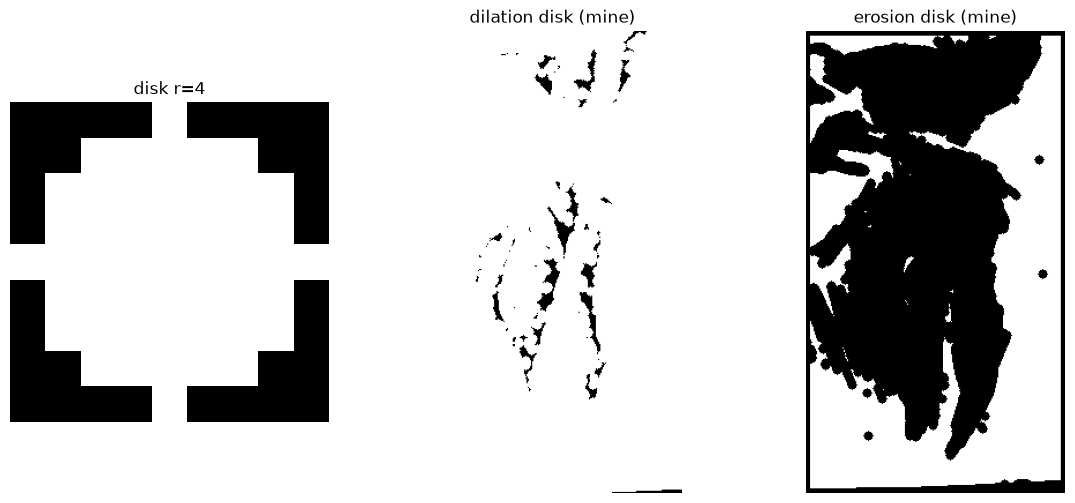

In [9]:
# Тот же пайплайн с круглым SE — достаточно подменить матрицу
SE_circle = se_disk(4)
print(SE_circle)

my_dil_c = dilate(binary, SE_circle)
lib_dil_c = library_dilate(binary, SE_circle)
_ = compare(my_dil_c, lib_dil_c, "dilation disk r=4")

fig, ax = plt.subplots(1, 3, figsize=(14, 6))
ax[0].imshow(SE_circle, cmap="gray", vmin=0, vmax=1)
ax[0].set_title("disk r=4")
ax[1].imshow(my_dil_c, cmap="gray")
ax[1].set_title("dilation disk (mine)")
ax[2].imshow(erode(binary, SE_circle), cmap="gray")
ax[2].set_title("erosion disk (mine)")
for a in ax:
    a.axis("off")
plt.show()